In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')

if src_path not in sys.path:
    sys.path.append(src_path)

In [2]:
from utils import load_data, transform_data
from data_vis import plot_candlestick, plot_time_series, plot_normalized_pair, plot_series
from comp_utils import find_best_pair_for_ticker, get_pairs, get_residuals

In [192]:
btc_data = transform_data(load_data("BTCUSDT"))
eth_data = transform_data(load_data("ETHUSDT"))
ada_data = transform_data(load_data("ADAUSDT"))
bnb_data = transform_data(load_data("BNBUSDT"))
doge_data = transform_data(load_data("DOGEUSDT"))
link_data = transform_data(load_data("LINKUSDT"))
sol_data = transform_data(load_data("SOLUSDT"))
wbtc_data = transform_data(load_data("WBTC"))
xrp_data = transform_data(load_data("XRPUSDT"))
usdc_data = transform_data(load_data("USDCUSDT"))
avax_data = transform_data(load_data("AVAXUSDT"))
bch_data = transform_data(load_data("BCHUSDT"))
dai_data = transform_data(load_data("DAIUSDT"))
ltc_data = transform_data(load_data("LTCUSDT"))
xlm_data = transform_data(load_data("XLMUSDT"))

In [197]:
btc_data[0:650000]

,open_time,open,high,low,close,volume,close_time,quote_volume,count,taker_buy_base_volume,taker_buy_quote_volume,mid
0,2024-01-01 00:00:00,42278.79,42299.56,42278.79,42278.80,0.01092,1704067259999,461.785135,6,0.01046,442.336887,42278.795
1,2024-01-01 00:01:00,42278.80,42326.09,42278.80,42326.09,1.08172,1704067319999,45759.153480,17,0.53911,22818.105541,42302.445
2,2024-01-01 00:02:00,42310.58,42334.95,42303.15,42303.15,0.06211,1704067379999,2627.608250,11,0.00146,61.804933,42306.865
3,2024-01-01 00:03:00,42334.94,42378.76,42309.72,42338.87,0.16069,1704067439999,6808.410461,35,0.15478,6558.188452,42336.905
4,2024-01-01 00:04:00,42340.08,42415.39,42340.08,42415.34,0.15896,1704067499999,6739.551883,45,0.14716,6239.619389,42377.710
...,...,...,...,...,...,...,...,...,...,...,...,...
649995,2025-03-28 09:15:00,85204.21,85204.21,85204.21,85204.21,0.00000,1743153359999,0.000000,0,0.00000,0.000000,85204.210
649996,2025-03-28 09:16:00,85204.21,85204.21,85204.21,85204.21,0.00000,1743153419999,0.000000,0,0.00000,0.000000,85204.210
649997,2025-03-28 09:17:00,85121.07,85121.07,85119.59,85119.59,0.00348,1743153479999,296.219960,3,0.00000,0.000000,85120.330
649998,2025-03-28 09:18:00,85111.25,85111.25,85086.62,85086.62,0.02391,1743153539999,2034.934220,4,0.00000,0.000000,85098.935


In [4]:
data_dict = {
    "BTCUSDT": btc_data, 
    "ETHUSDT": eth_data, 
    "ADAUSDT": ada_data, 
    "BNBUSDT": bnb_data, 
    "DOGEUSDT": doge_data, 
    "LINKUSDT": link_data,
    "SOLUSDT": sol_data, 
    "WBTC": wbtc_data, 
    "XRPUSDT": xrp_data, 
    "BCHUSDT": dai_data,
    "DAIUSDT": dai_data,
    "LTCUSDT": ltc_data,
    "XLMUSDT": xlm_data,
    "AVAXUSDT": avax_data,
}

### Augmented Dickey-Fuller, Phillips Perron, KPSS test for stationarity
#### 1. Test the price series of each asset, and the first difference series of each asset

In [5]:
from arch.unitroot import ADF, PhillipsPerron, KPSS

In [6]:
def unit_root_summary(series, name="Series"):
    print(f"\n Unit Root Tests for: {name}")
    print("="*60)

    # ADF Test
    adf = ADF(series)
    print("\n Augmented Dickey-Fuller (ADF) Test")
    print(f"Test Statistic: {adf.stat:.4f}")
    print(f"p-value       : {adf.pvalue:.4f}")
    print(f"Lags Used     : {adf.lags}")
    print(f"Null Hypothesis: Non-stationary (has unit root)")

    # Phillips-Perron Test
    pp = PhillipsPerron(series)
    print("\n Phillips-Perron (PP) Test")
    print(f"Test Statistic: {pp.stat:.4f}")
    print(f"p-value       : {pp.pvalue:.4f}")
    print(f"Lags Used     : {pp.lags}")
    print(f"Null Hypothesis: Non-stationary (has unit root)")

    # KPSS Test
    kpss = KPSS(series)
    print("\n KPSS Test")
    print(f"Test Statistic: {kpss.stat:.4f}")
    print(f"p-value       : {kpss.pvalue:.4f}")
    print(f"Lags Used     : {kpss.lags}")
    print(f"Null Hypothesis: Stationary")

    print("="*60)


In [7]:
diff = ltc_data['mid'].diff().dropna()
mid = ltc_data['mid']

In [8]:
# example of the statistical testing
unit_root_summary(mid, name="LTCUSDT Mid Price")


 Unit Root Tests for: LTCUSDT Mid Price

 Augmented Dickey-Fuller (ADF) Test
Test Statistic: -2.3726
p-value       : 0.1496
Lags Used     : 105
Null Hypothesis: Non-stationary (has unit root)

 Phillips-Perron (PP) Test
Test Statistic: -2.4301
p-value       : 0.1334
Lags Used     : 108
Null Hypothesis: Non-stationary (has unit root)

 KPSS Test
Test Statistic: 51.3553
p-value       : 0.0001
Lags Used     : 453
Null Hypothesis: Stationary


#### 2. For every basket of three assets, regress one against the other two and test the residuals for stationarity 

$$ \text{ASSET}_0 = \alpha + \beta_1 \text{ASSET}_1 + \beta_2 \text{ASSET}_2 + \epsilon_t $$ 

In [9]:
import itertools
import statsmodels.api as sm
from joblib import Parallel, delayed

In [10]:
"""symbols = list(data_dict.keys())

prices = pd.concat({sym: data_dict[sym]['mid'] for sym in symbols}, axis=1)
prices.columns.name = None
prices = prices.dropna()

def process_combination(dep, indep1, indep2, prices_df):
    Y = prices_df[dep]
    X = prices_df[[indep1, indep2]]
    X = sm.add_constant(X)

    model = sm.OLS(Y, X).fit()
    residuals = model.resid

    return {
        'dependent': dep,
        'independent': [indep1, indep2],
        'alpha': model.params['const'],
        'betas': model.params.drop('const'),
        'residuals': residuals,
        'adj_r2': model.rsquared_adj
    }

jobs = []
for combo in itertools.combinations(prices.columns, 3):
    for dep, indep1, indep2 in itertools.permutations(combo, 3):
        jobs.append((dep, indep1, indep2))

results = Parallel(n_jobs=-1)(
    delayed(process_combination)(dep, indep1, indep2, prices)
    for dep, indep1, indep2 in jobs
)"""

"symbols = list(data_dict.keys())\n\nprices = pd.concat({sym: data_dict[sym]['mid'] for sym in symbols}, axis=1)\nprices.columns.name = None\nprices = prices.dropna()\n\ndef process_combination(dep, indep1, indep2, prices_df):\n    Y = prices_df[dep]\n    X = prices_df[[indep1, indep2]]\n    X = sm.add_constant(X)\n\n    model = sm.OLS(Y, X).fit()\n    residuals = model.resid\n\n    return {\n        'dependent': dep,\n        'independent': [indep1, indep2],\n        'alpha': model.params['const'],\n        'betas': model.params.drop('const'),\n        'residuals': residuals,\n        'adj_r2': model.rsquared_adj\n    }\n\njobs = []\nfor combo in itertools.combinations(prices.columns, 3):\n    for dep, indep1, indep2 in itertools.permutations(combo, 3):\n        jobs.append((dep, indep1, indep2))\n\nresults = Parallel(n_jobs=-1)(\n    delayed(process_combination)(dep, indep1, indep2, prices)\n    for dep, indep1, indep2 in jobs\n)"

In [11]:
"""regression_results = pd.DataFrame(results)
regression_results"""

'regression_results = pd.DataFrame(results)\nregression_results'

In [12]:
"""strong_models = regression_results[regression_results['adj_r2'] > 0.90]
strong_models = strong_models.reset_index(drop=True)
strong_models"""

"strong_models = regression_results[regression_results['adj_r2'] > 0.90]\nstrong_models = strong_models.reset_index(drop=True)\nstrong_models"

#### Now let's test the residuals series for cointegration

In [13]:
"""def compute_adf(residual_series):
    adf = ADF(residual_series)
    return adf.stat, adf.pvalue

adf_results = Parallel(n_jobs=-1)(
    delayed(compute_adf)(resid) for resid in strong_models['residuals']
)


strong_models['adf_stat'] = [res[0] for res in adf_results]
strong_models['adf_pvalue'] = [res[1] for res in adf_results]"""

"def compute_adf(residual_series):\n    adf = ADF(residual_series)\n    return adf.stat, adf.pvalue\n\nadf_results = Parallel(n_jobs=-1)(\n    delayed(compute_adf)(resid) for resid in strong_models['residuals']\n)\n\n\nstrong_models['adf_stat'] = [res[0] for res in adf_results]\nstrong_models['adf_pvalue'] = [res[1] for res in adf_results]"

In [14]:
models = pd.read_csv('models_0.9.csv')

In [15]:
cointegrated_models = models[models['adf_pvalue'] < 0.05]
cointegrated_models = cointegrated_models[cointegrated_models['adj_r2'] != 1.0]
cointegrated_models

,dependent,independent,alpha,betas,residuals,adj_r2,adf_pvalue,adf_stat
0,BTCUSDT,"['ADAUSDT', 'BNBUSDT']",-5754.346689,ADAUSDT 38811.088171\nBNBUSDT 96.0449...,0 -4947.136649\n1 -4965.785742\n...,0.910160,0.005037,-3.640232
1,BTCUSDT,"['BNBUSDT', 'ADAUSDT']",-5754.346689,BNBUSDT 96.044960\nADAUSDT 38811.0881...,0 -4947.136649\n1 -4965.785742\n...,0.910160,0.005037,-3.640232
2,XLMUSDT,"['BTCUSDT', 'ADAUSDT']",-0.212639,BTCUSDT 0.000003\nADAUSDT 0.365676\ndtyp...,0 0.016572\n1 0.016475\n2 ...,0.914772,0.002907,-3.800076
3,XLMUSDT,"['ADAUSDT', 'BTCUSDT']",-0.212639,ADAUSDT 0.365676\nBTCUSDT 0.000003\ndtyp...,0 0.016572\n1 0.016475\n2 ...,0.914772,0.002907,-3.800076
4,BTCUSDT,"['BNBUSDT', 'XRPUSDT']",13853.554315,BNBUSDT 78.720384\nXRPUSDT 12457.2514...,0 -3778.294303\n1 -3786.132456\n...,0.926725,0.010979,-3.399419
5,BTCUSDT,"['XRPUSDT', 'BNBUSDT']",13853.554315,XRPUSDT 12457.251429\nBNBUSDT 78.7203...,0 -3778.294303\n1 -3786.132456\n...,0.926725,0.010979,-3.399419
6,BTCUSDT,"['BNBUSDT', 'XLMUSDT']",11448.581912,BNBUSDT 80.364654\nXLMUSDT 78569.4049...,0 -4343.207291\n1 -4351.703152\n...,0.923206,0.001920,-3.915985
7,BTCUSDT,"['XLMUSDT', 'BNBUSDT']",11448.581912,XLMUSDT 78569.404996\nBNBUSDT 80.3646...,0 -4343.207291\n1 -4351.703152\n...,0.923206,0.001920,-3.915985
8,BTCUSDT,"['SOLUSDT', 'XRPUSDT']",24433.269827,SOLUSDT 194.180696\nXRPUSDT 15515.0174...,0 -11433.317049\n1 -11440.735960...,0.900739,0.002731,-3.817769
9,BTCUSDT,"['XRPUSDT', 'SOLUSDT']",24433.269827,XRPUSDT 15515.017401\nSOLUSDT 194.1806...,0 -11433.317049\n1 -11440.735960...,0.900739,0.002731,-3.817769


In [16]:
import re
import ast

In [17]:
# ---- Helpers ----
def parse_independent(indep_raw):
    """Converts a stringified list into a list"""
    if isinstance(indep_raw, str):
        return ast.literal_eval(indep_raw)
    return indep_raw

def parse_betas(betas_raw):
    """Converts a stringified Series into a proper Series"""
    if isinstance(betas_raw, pd.Series):
        return betas_raw
    elif isinstance(betas_raw, dict):
        return pd.Series(betas_raw)
    elif isinstance(betas_raw, str):
        lines = betas_raw.strip().split("\n")
        beta_dict = {}
        for line in lines:
            parts = re.split(r'\s{2,}', line.strip())
            if len(parts) == 2:
                key, val = parts
                try:
                    beta_dict[key] = float(val)
                except ValueError:
                    continue
        return pd.Series(beta_dict)
    else:
        raise ValueError("Unknown beta format")

# ---- Spread Computation ----

spreads = []

for i, row in cointegrated_models.iterrows():
    dep = row['dependent']
    indep = parse_independent(row['independent'])
    alpha = row['alpha']
    betas = parse_betas(row['betas'])

    try:
        spread = (
            data_dict[dep]['mid']
            - betas[indep[0]] * data_dict[indep[0]]['mid']
            - betas[indep[1]] * data_dict[indep[1]]['mid']
            - alpha
        )

        spreads.append({
            'dependent': dep,
            'independent': indep,
            'spread': spread
        })
    
    except KeyError as e:
        print(f"Skipping {dep} ~ {indep} due to missing key: {e}")

In [18]:
spreads = pd.DataFrame(spreads)
spreads

,dependent,independent,spread
0,BTCUSDT,"[ADAUSDT, BNBUSDT]",0 -4947.136529 1 -4965.785622 2 ...
1,BTCUSDT,"[BNBUSDT, ADAUSDT]",0 -4947.136529 1 -4965.785622 2 ...
2,XLMUSDT,"[BTCUSDT, ADAUSDT]",0 -0.002462 1 -0.002570 2 ...
3,XLMUSDT,"[ADAUSDT, BTCUSDT]",0 -0.002462 1 -0.002570 2 ...
4,BTCUSDT,"[BNBUSDT, XRPUSDT]",0 -3778.294381 1 -3786.132535 2 ...
5,BTCUSDT,"[XRPUSDT, BNBUSDT]",0 -3778.294381 1 -3786.132535 2 ...
6,BTCUSDT,"[BNBUSDT, XLMUSDT]",0 -4343.207160 1 -4351.703021 2 ...
7,BTCUSDT,"[XLMUSDT, BNBUSDT]",0 -4343.207160 1 -4351.703021 2 ...
8,BTCUSDT,"[SOLUSDT, XRPUSDT]",0 -11433.317069 1 -11440.735980 ...
9,BTCUSDT,"[XRPUSDT, SOLUSDT]",0 -11433.317069 1 -11440.735980 ...


In [181]:
spread1 = spreads['spread'][10]

In [182]:
scaled_spread = spread1 * 1

##### Mean reversion rate is pretty slow so we may have to design our strategy with wider trading thresholds

### Building and Simulating the Strategy

In [183]:
from backtesting import simulate_statarb

In [184]:
prices_df = pd.concat(
    {symbol: df['mid'] for symbol, df in data_dict.items()},
    axis=1
)

prices_df.columns.name = None
prices_df = prices_df.dropna()

In [185]:
spread_weights = {
    "BTCUSDT": 1.0,
    "SOLUSDT": -1*15515.017401,
    "XRPUSDT": -1*194.180696
}

In [186]:
testing_df = simulate_statarb(scaled_spread, window=720, threshold=1.0).dropna()
testing_df

,spread,mean,std,z,position,spread_return,shifted_position,pnl,position_change,transaction_cost,cum_pnl
720,0.099259,0.098949,0.001553,0.199396,0,0.001327,0.0,0.0,0.0,0.0,0.000000
721,0.099374,0.098950,0.001553,0.272650,0,0.000115,0.0,0.0,0.0,0.0,0.000000
722,0.099374,0.098952,0.001553,0.271972,0,0.000000,0.0,0.0,0.0,0.0,0.000000
723,0.099374,0.098953,0.001553,0.271294,0,0.000000,0.0,0.0,0.0,0.0,0.000000
724,0.099374,0.098954,0.001553,0.270388,0,0.000000,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
655195,0.046165,0.039790,0.004318,1.476592,-1,0.000000,-1.0,-0.0,0.0,0.0,15.111654
655196,0.046165,0.039805,0.004321,1.471911,-1,0.000000,-1.0,-0.0,0.0,0.0,15.111654
655197,0.046165,0.039819,0.004325,1.467256,-1,0.000000,-1.0,-0.0,0.0,0.0,15.111654
655198,0.046165,0.039833,0.004329,1.462626,-1,0.000000,-1.0,-0.0,0.0,0.0,15.111654


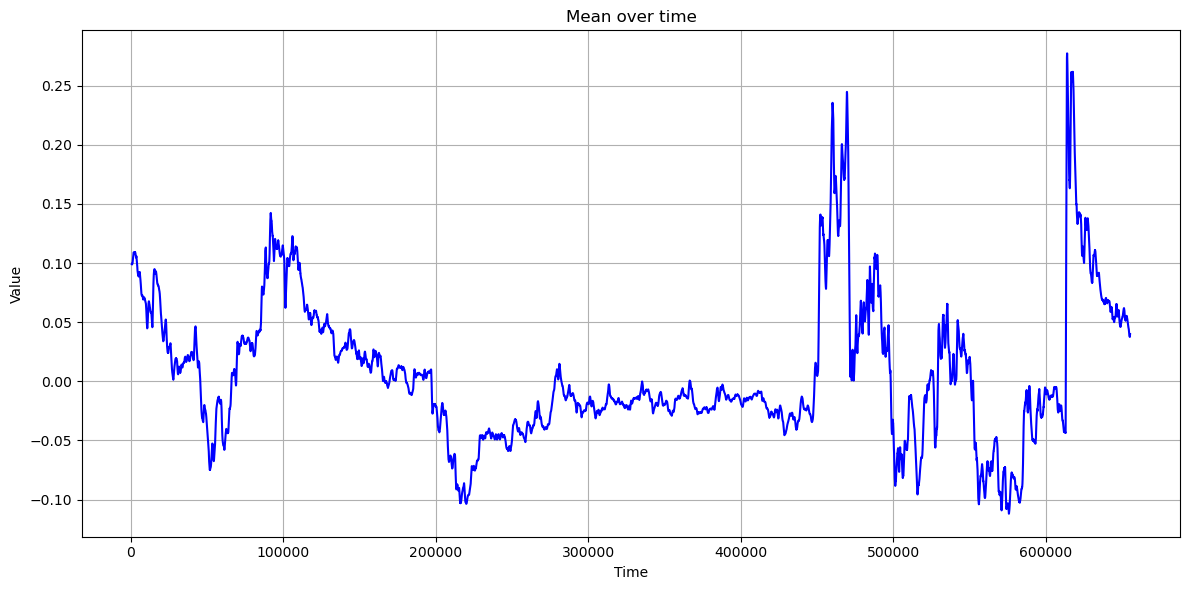

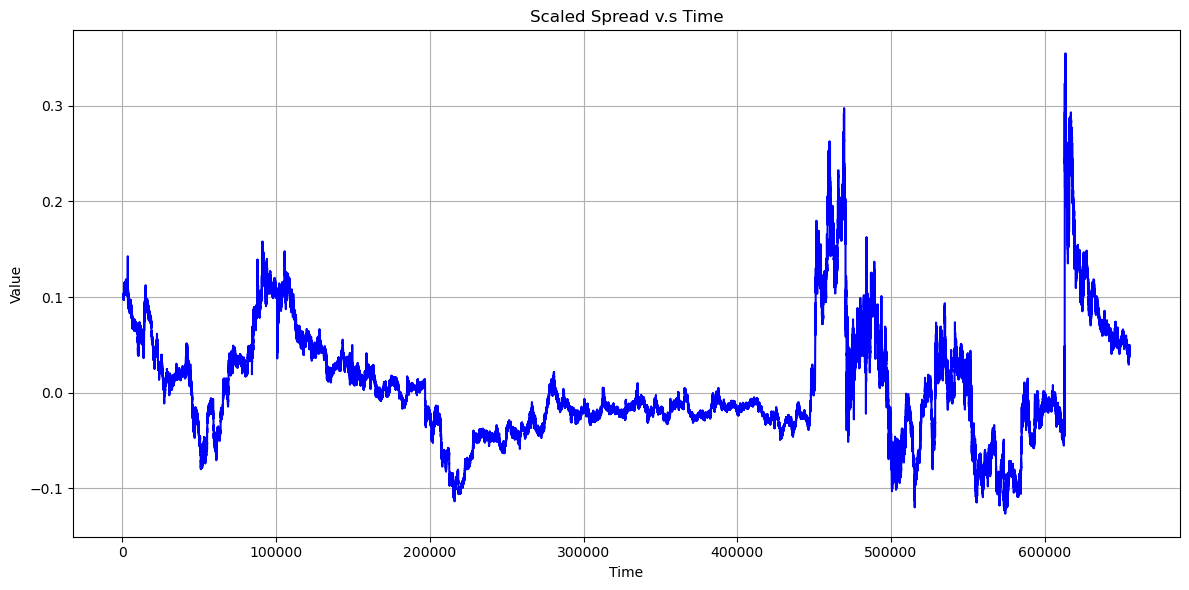

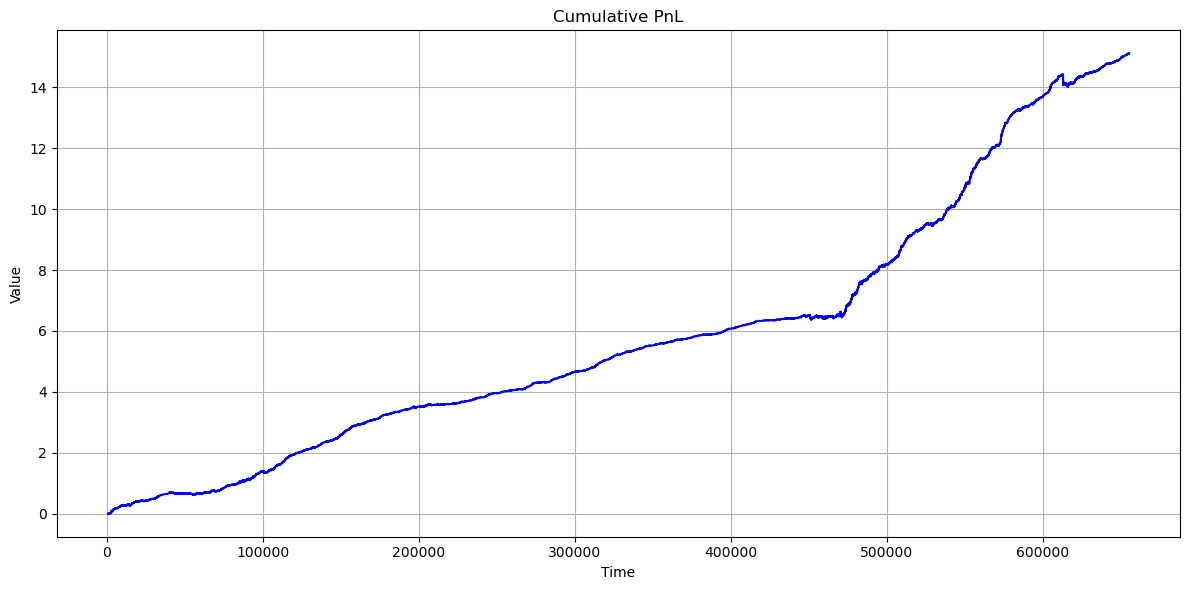

In [187]:
plot_series(testing_df['mean'], title="Mean over time")
plot_series(testing_df['spread'], title="Scaled Spread v.s Time")
plot_series(testing_df['cum_pnl'], title="Cumulative PnL")